# SM neutrino cross sections and total rates

Summary of every SM scattering channel used across the MINT studies, in the
style of the BIN\_MC `plot_xsec_data` summary panels ($\sigma/E$ per nucleon
of standard rock, $Z/A = 0.5$; electron-target channels carry the $Z/A$
factor, coherent-scale channels the $Z^2/A$ scaling from their reference
nucleus). Channels:

- **DIS**: total CC (light+charm+bottom), NC, CC charm, and the
  $\tau$-producing chain $\nu_\ell N \to \ell\, D_s(\to\tau\nu_\tau)\,X$
  ($f_{c\to D_s}\,{\rm BR} = 0.08 \times 5.32\%$; the $D^\pm$ branch adds
  another $\sim 7\%$ on top and is left out here); $\nu_\tau$ CC with the
  $\tau$-mass threshold factor.
- **Electron targets**: elastic $\nu e$ scattering, inverse muon decay
  ($\nu_\mu e^-\to\mu^-\nu_e$, $\bar\nu_e e^-\to\mu^-\bar\nu_\mu$), inverse
  tau decay ($\bar\nu_e e^-\to\tau^-\bar\nu_\tau$), and the $s$-channel
  meson resonances $\rho^-$, $K^{*-}$ (tabulated improved shapes) and
  $D^{*-}$, $D_s^{*-}$ (Breit–Wigner needles with
  $\Gamma_{e\nu} = G_F^2 f^2 M^3 |V_{\rm CKM}|^2/12\pi$; total widths
  83.4 keV measured and $\sim$70 eV theory, respectively — on this axis they
  are vertical lines whose *area* $\int\sigma\,dE$ is the physical quantity,
  annotated).
- **Tridents** $\nu N \to \nu \ell^+\ell^-N$ (tabulated O16 curves scaled
  $\propto Z^2/A$).

The rates section folds these with the simulated MuC fluxes at the standard
5 km gas+W detector.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import mint
mint.xsecs.use_backend("ct18")   # PDF-consistent LO CT18NNLO cross sections
from mint import const
from mint import xsecs
from mint import detector_tools as dt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

import nutau_secondary as nts

In [2]:
Z, A = 11, 22          # standard rock (Z/A = 0.5)
E = np.geomspace(50, 15e3, 10_000)

xs = {nui: xsecs.get_cross_sections(E, nui=nui, Z=Z, A=A)
      for nui in ("nue", "numu", "nuebar", "numubar")}

# total CC cross section per nucleon: single implementation in mint.xsecs
sigma_cc_tot = xsecs.sigma_CC

def sigma_chain(E_, nui):
    # nu_l N -> l D_s X with D_s -> tau nu: the tau-producing charm chain
    return nts.sigma_charm_cc(E_, nui) * nts.F_DS * nts.BR_DS_TAUNU

# D*- / D_s*- resonances: BW (Brdar et al. Eq. 1, J = 1) on locally dense grids
VRES = {
    r"$D^{*-}$": (2.0103, 0.25, 0.221**2, 8.34e-5),   # M, f, |V|^2, Gamma_tot [GeV]
    r"$D_s^{*-}$": (2.1122, 0.274, 0.975**2, 7.0e-8),
}

def bw_curve(M, f, v2, Gtot, n_fwhm=60, npts=6001):
    # per-electron sigma(E) around the peak; FWHM in E_nu is M Gamma / m_e
    me = const.m_e
    gam_enu = const.Gf**2 * f**2 * M**3 * v2 / (12 * np.pi)
    E_res = (M**2 - me**2) / (2 * me)
    fwhm = M * Gtot / me
    Eg = E_res + np.linspace(-n_fwhm, n_fwhm, npts) * fwhm / 2
    s = 2 * me * Eg + me**2
    sig = (24 * np.pi * gam_enu * Gtot * (s / M**2)
           / ((s - M**2) ** 2 + M**2 * Gtot**2)) * const.invGeV2_to_cm2
    return Eg, sig

def nwa_strength(M, f, v2):
    # int sigma dE [cm^2 GeV] per electron (Br_fi = 1); total width cancels
    me = const.m_e
    gam_enu = const.Gf**2 * f**2 * M**3 * v2 / (12 * np.pi)
    return 24 * np.pi**2 * gam_enu / (2 * me * M) * const.invGeV2_to_cm2

for lab, (M, f, v2, Gtot) in VRES.items():
    E_res = (M**2 - const.m_e**2) / (2 * const.m_e)
    print(f"{lab}: E_res = {E_res:.0f} GeV, int sigma dE = {nwa_strength(M, f, v2):.2e} cm^2 GeV/electron")

$D^{*-}$: E_res = 3954 GeV, int sigma dE = 4.02e-36 cm^2 GeV/electron
$D_s^{*-}$: E_res = 4365 GeV, int sigma dE = 1.04e-34 cm^2 GeV/electron


## Validation: the Breit-Wigner method vs the tabulated $\rho^-/K^{*-}$ curves

The $D^{*-}/D_s^{*-}$ needles use paper Eq. 1 (J=1 BW) with
$\Gamma_{e\nu} = G_F^2 f^2 M^3 |V_{\rm CKM}|^2/12\pi$. Applying the *same*
method to $\rho^-$ and $K^{*-}$ and comparing with the tabulated curves
shipped in `mint.xsecs`: the $\rho^-$ shape and area are reproduced to
$\lesssim 4\%$ (the residual is the BW-vs-improved-form-factor difference
the paper quotes at $\sim 10\%$). The $K^{*-}$ **integrated strength** agrees
to 5% (and our narrow-width area matches our BW integral to 0.2%), while the
tabulated shape is $\sim 2.4\times$ taller/narrower than a PDG-width BW —
consistent with a digitization artifact of a narrow peak; rate-wise the two
are equivalent. Note the BW peak height is the unitarity-scale
$24\pi/M^2 \times {\rm Br}_{\rm in}$ and, for the ultra-narrow $D_s^{*-}$
($\Gamma \sim 70$ eV, theory), legitimately towers above the CC curve — just
as the Glashow resonance exceeds $\sigma_{CC}$ by $\times 350$ at 6.3 PeV.
Only the width-independent line **area** enters event rates (next section).

$\rho^-$: peak ratio 1.042 | area ratio 1.034
$K^{*-}$: peak ratio 0.408 | area ratio 1.027


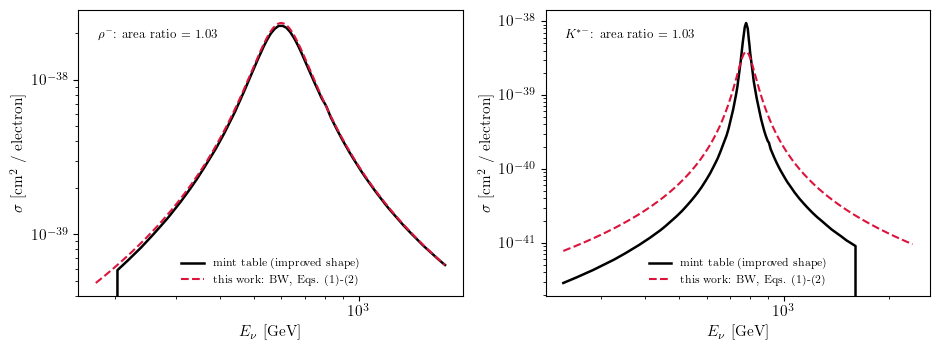

In [3]:
def bw_sigma(E, M, f, v2, Gtot):
    gam_enu = const.Gf**2 * f**2 * M**3 * v2 / (12*np.pi)
    s = 2*const.m_e*E + const.m_e**2
    return (24*np.pi * gam_enu * Gtot * (s/M**2)
            / ((s - M**2)**2 + M**2*Gtot**2)) * const.invGeV2_to_cm2

RES_LIGHT = {r"$\rho^-$": (0.7755, 0.210, 0.9737**2, 0.1491, xsecs.sigma_resonant_rho),
             r"$K^{*-}$": (0.8917, 0.204, 0.2243**2, 0.0514, xsecs.sigma_resonant_Kstar)}

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.6))
for ax, (lab, (M, f, v2, G, tab)) in zip(axs, RES_LIGHT.items()):
    E_res = M**2/(2*const.m_e)
    Ev = np.geomspace(0.3*E_res, 3*E_res, 4000)
    sig_bw, sig_tab = bw_sigma(Ev, M, f, v2, G), tab(Ev)
    ax.plot(Ev, sig_tab, color="black", lw=1.8, label="mint table (improved shape)")
    ax.plot(Ev, sig_bw, color="crimson", lw=1.5, ls="--", label="this work: BW, Eqs. (1)-(2)")
    r_area = np.trapezoid(sig_bw, Ev)/np.trapezoid(sig_tab, Ev)
    ax.annotate(lab + rf": area ratio = {r_area:.2f}", xy=(0.05, 0.9),
                xycoords="axes fraction", fontsize=9)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$\sigma$ [cm$^2$ / electron]")
    ax.legend(frameon=False, fontsize=8, loc="lower center")
    print(f"{lab}: peak ratio {sig_bw.max()/sig_tab.max():.3f} | area ratio {r_area:.3f}")
fig.tight_layout()
fig.savefig("plots/xsec_summary_resonance_validation.pdf", bbox_inches="tight", dpi=300)

### Backend cross-check: MINT's LO+CT18NNLO vs the NNLO tables

`mint.xsecs.use_backend("ct18")` switches every DIS cross section to MINT's
own LO calculation with CT18NNLO PDFs (`mint.lo_dis`; same PDF set, member
and $Q^2 > 2$ GeV$^2$ cut as the differential samplers; cached interpolators,
table build $\sim$0.1 s). The ratio to the shipped NNLO tables doubles as a
validation of the event-by-event DIS model: CC channels agree at the
$\sim$10% level (the expected size of the missing NLO corrections), while
the real NC calculation exposes the limitation of the tables' flat
$0.335\times$CC$_{\rm light}$ approximation — the true $\sigma_{\rm
NC}/\sigma_{\rm CC}$ differs between $\nu$ ($\approx0.32$) and $\bar\nu$
($\approx0.37$). The default backend remains "alfonso" everywhere.

mean CC-total ratio 0.3-5 TeV: 0.878


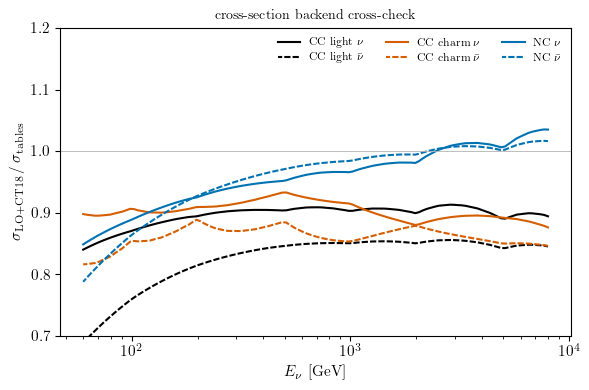

In [4]:
Eb = np.geomspace(60., 8e3, 120)
channels = [("CC light $\\nu$", xsecs.sigma_lightquark_CC_nu, "-", "k"),
            ("CC light $\\bar\\nu$", xsecs.sigma_lightquark_CC_nubar, (1, (3, 1)), "k"),
            ("CC charm $\\nu$", xsecs.sigma_charm_CC_nu, "-", "#D55E00"),
            ("CC charm $\\bar\\nu$", xsecs.sigma_charm_CC_nubar, (1, (3, 1)), "#D55E00"),
            ("NC $\\nu$", xsecs.sigma_NC_nu, "-", "#0072B2"),
            ("NC $\\bar\\nu$", xsecs.sigma_NC_nubar, (1, (3, 1)), "#0072B2")]

xsecs.use_backend("alfonso")
ref = {n: np.asarray(f(Eb), float).copy() for n, f, *_ in channels}
xsecs.use_backend("ct18")
new = {n: np.asarray(f(Eb), float) for n, f, *_ in channels}
xsecs.use_backend("ct18")               # leave the notebook on the paper default

fig, ax = plt.subplots(figsize=(6, 4))
for n, f, ls, c in channels:
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(ref[n] > 0, new[n] / ref[n], np.nan)
    ax.plot(Eb, r, ls=ls, color=c, lw=1.5, label=n)
ax.axhline(1.0, color="0.7", lw=0.6)
ax.set_xscale("log")
ax.set_ylim(0.7, 1.2)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\sigma_{\rm LO+CT18}\,/\,\sigma_{\rm tables}$")
ax.legend(frameon=False, fontsize=8, ncol=3)
ax.set_title("cross-section backend cross-check", fontsize=10)
plt.tight_layout()
fig.savefig("plots/xsec_backend_crosscheck.pdf", bbox_inches="tight", dpi=300)
print("mean CC-total ratio 0.3-5 TeV:",
      f"{np.mean([(new[n]/ref[n])[(Eb>300)&(Eb<5000)].mean() for n in list(ref)[:2]]):.3f}")

## $\nu_e/\bar\nu_e$ and $\nu_\mu/\bar\nu_\mu$ panels

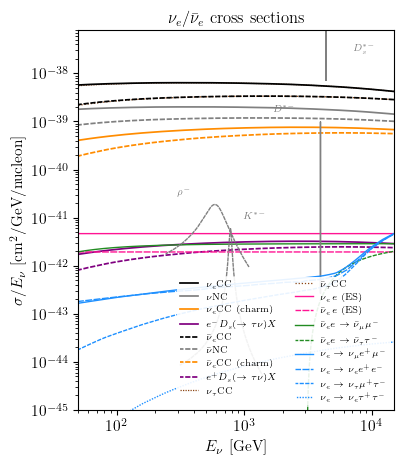

In [5]:
fig, ax = pt.std_fig(figsize=(4.0, 5.0))

ax.plot(E, sigma_cc_tot(E, "nue") / E, ls='-', label=r'$\nu_e$CC', c='black', lw=1.25)
ax.plot(E, xs['nue']['nue_NC'] / E, ls='-', label=r'$\nu$NC', c='grey', lw=1.25)
ax.plot(E, xs['nue']['nue_CC_charm'] / E, ls='-', label=r'$\nu_e$CC (charm)', c='darkorange', lw=1.25)
ax.plot(E, sigma_chain(E, "nue") / E, ls='-', label=r'$e^-D_s(\to\tau\nu)X$', c='purple', lw=1.25)

ax.plot(E, sigma_cc_tot(E, "nuebar") / E, ls=(1, (3, 1)), label=r'$\bar\nu_e$CC', c='black', lw=1.25)
ax.plot(E, xs['nuebar']['nuebar_NC'] / E, ls=(1, (3, 1)), label=r'$\bar\nu$NC', c='grey', lw=1.25)
ax.plot(E, xs['nuebar']['nuebar_CC_charm'] / E, ls=(1, (3, 1)), label=r'$\bar\nu_e$CC (charm)', c='darkorange', lw=1.25)
ax.plot(E, sigma_chain(E, "nuebar") / E, ls=(1, (3, 1)), label=r'$e^+D_s(\to\tau\nu)X$', c='purple', lw=1.25)

ax.plot(E, xsecs.sigma_nutau_CC(E) / E, ls=(0, (1, 1)), label=r'$\nu_\tau$CC', c='saddlebrown', lw=0.9, zorder=1)
ax.plot(E, xsecs.sigma_nutaubar_CC(E) / E, ls=(0, (1, 1.5)), label=r'$\bar\nu_\tau$CC', c='saddlebrown', lw=0.9, zorder=1)

ax.plot(E, xs['nue']['nue_ES_e'] / E, ls='-', label=r'$\nu_e\, e$ (ES)', c='deeppink', lw=1)
ax.plot(E, xs['nuebar']['nuebar_ES_e'] / E, ls=(1, (5, 1)), label=r'$\bar\nu_e\, e$ (ES)', c='deeppink', lw=1)

ax.plot(E, xs['nuebar']['nuebar_invdecay_mu'] / E, ls='-',
        label=r'$\bar\nu_e e \to \bar\nu_\mu\mu^-$', c='forestgreen', lw=1)
ax.plot(E, xs['nuebar']['nuebar_invdecay_tau'] / E, ls=(1, (3, 1)),
        label=r'$\bar\nu_e e \to \bar\nu_\tau\tau^-$', c='forestgreen', lw=1)

# resonances (nuebar e- only): tabulated rho/K*, BW needles for D*/Ds*
for key, tex, xf in [('nuebar_resonant_rho-', r'$\rho^-$', 0.55),
                     ('nuebar_resonant_Kstar-', r'$K^{*-}$', 1.55)]:
    y = xs['nuebar'][key]
    E_at_max = E[np.argmax(y)]
    m_ = (E < E_at_max * 1.8) & (E > E_at_max * 0.4)
    ax.plot(E[m_], y[m_] / E[m_], lw=1, ls=(1, (3, 0.5)), c='grey')
    ax.annotate(tex, xy=(E_at_max * xf, 1.6 * np.max(y / E)), fontsize=7,
                color='grey', ha='center')
for lab, (xf, yv) in [(r"$D^{*-}$", (0.52, 1.6e-39)),
                      (r"$D_s^{*-}$", (2.0, 3.0e-38))]:
    M, f, v2, Gtot = VRES[lab]
    Eg, sig = bw_curve(M, f, v2, Gtot)
    ax.plot(Eg, sig * (Z / A) / Eg, lw=1, c='grey')
    ax.annotate(lab, xy=((M**2 / (2 * const.m_e)) * xf, yv), fontsize=7,
                color='grey', ha='center')

ax.plot(E, xs['nue']['nue_mem_tri'] / E, ls='-', label=r'$\nu_e \to \nu_\mu e^+\mu^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['nue']['nue_eee_tri'] / E, ls=(1, (5, 1)), label=r'$\nu_e \to \nu_e e^+e^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['nue']['nue_lel_tri'] / E, ls=(1, (3, 1)), label=r'$\nu_e \to \nu_\tau \mu^+\tau^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['nue']['nue_ell_tri'] / E, ls=(1, (1, 1)), label=r'$\nu_e \to \nu_e \tau^+\tau^-$', c='dodgerblue', lw=1)

ax.set_xlim(E.min(), E.max())
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-45, 8e-38)
ax.set_ylabel(r'$\sigma/E_\nu$ [cm$^2$/GeV/nucleon]')
ax.set_xlabel(r'$E_{\nu}$ [GeV]')
ax.set_title(r'$\nu_e/\bar\nu_e$ cross sections')
ax.legend(loc='lower right', ncol=2, frameon=True, fontsize=6.5, framealpha=0.9, edgecolor='None')
fig.savefig('plots/xsec_summary_e.pdf', bbox_inches='tight', dpi=300)

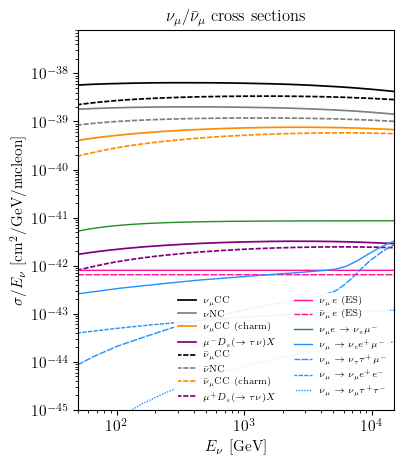

In [6]:
fig, ax = pt.std_fig(figsize=(4.0, 5.0))

ax.plot(E, sigma_cc_tot(E, "numu") / E, ls='-', label=r'$\nu_\mu$CC', c='black', lw=1.25)
ax.plot(E, xs['numu']['numu_NC'] / E, ls='-', label=r'$\nu$NC', c='grey', lw=1.25)
ax.plot(E, xs['numu']['numu_CC_charm'] / E, ls='-', label=r'$\nu_\mu$CC (charm)', c='darkorange', lw=1.25)
ax.plot(E, sigma_chain(E, "numu") / E, ls='-', label=r'$\mu^-D_s(\to\tau\nu)X$', c='purple', lw=1.25)

ax.plot(E, sigma_cc_tot(E, "numubar") / E, ls=(1, (3, 1)), label=r'$\bar\nu_\mu$CC', c='black', lw=1.25)
ax.plot(E, xs['numubar']['numubar_NC'] / E, ls=(1, (3, 1)), label=r'$\bar\nu$NC', c='grey', lw=1.25)
ax.plot(E, xs['numubar']['numubar_CC_charm'] / E, ls=(1, (3, 1)), label=r'$\bar\nu_\mu$CC (charm)', c='darkorange', lw=1.25)
ax.plot(E, sigma_chain(E, "numubar") / E, ls=(1, (3, 1)), label=r'$\mu^+D_s(\to\tau\nu)X$', c='purple', lw=1.25)

ax.plot(E, xs['numu']['numu_ES_e'] / E, ls='-', label=r'$\nu_\mu\, e$ (ES)', c='deeppink', lw=1)
ax.plot(E, xs['numubar']['numubar_ES_e'] / E, ls=(1, (5, 1)), label=r'$\bar\nu_\mu\, e$ (ES)', c='deeppink', lw=1)

ax.plot(E, xs['numu']['numu_invdecay_mu'] / E, ls='-',
        label=r'$\nu_\mu e \to \nu_e\mu^-$', c='forestgreen', lw=1)

ax.plot(E, xs['numu']['numu_eme_tri'] / E, ls='-', label=r'$\nu_\mu \to \nu_e e^+\mu^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['numu']['numu_lml_tri'] / E, ls=(1, (5, 1)), label=r'$\nu_\mu \to \nu_\tau \tau^+\mu^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['numu']['numu_mee_tri'] / E, ls=(1, (3, 1)), label=r'$\nu_\mu \to \nu_\mu e^+e^-$', c='dodgerblue', lw=1)
ax.plot(E, xs['numu']['numu_mll_tri'] / E, ls=(1, (1, 1)), label=r'$\nu_\mu \to \nu_\mu \tau^+\tau^-$', c='dodgerblue', lw=1)

ax.set_xlim(E.min(), E.max())
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-45, 8e-38)
ax.set_ylabel(r'$\sigma/E_\nu$ [cm$^2$/GeV/nucleon]')
ax.set_xlabel(r'$E_{\nu}$ [GeV]')
ax.set_title(r'$\nu_\mu/\bar\nu_\mu$ cross sections')
ax.legend(loc='lower right', ncol=2, frameon=True, fontsize=6.5, framealpha=0.9, edgecolor='None')
fig.savefig('plots/xsec_summary_mu.pdf', bbox_inches='tight', dpi=300)

## Total rates at the standard detector

Events per year in the 5 km gas+W detector (10 m of 10-bar GAr + 3$\times$5 cm
W slabs, 2 m radius face) for each channel, folding the simulated fluxes of
both beams: the $\mu^+$ beam sends $\bar\nu_\mu + \nu_e$ downstream, the
$\mu^-$ beam sends $\nu_\mu + \bar\nu_e$ upstream. Nucleon channels use the
nucleon column, electron channels the electron column; $\rho^-/K^{*-}$ rates
integrate the tabulated shapes against the flux directly (the widths are
resolved by the flux MC), while the ultra-narrow $D^{*-}/D_s^{*-}$ use the
narrow-width line strength times $d\Phi/dE$ at $E_{\rm res}$. Tridents are
omitted from the bar chart (their $Z^2/A$ coherent scaling makes the W-slab
column strongly material-dependent).

In [7]:
ring, sims, injections_per_year = mint.beams.both_beams(n_evals=5e5)
det = mint.detectors.load("benchmark_5km")
DIST, DET_R = det.dist, det.radius
DET_L = det.fiducial_length

fluxes = {"down": [(fl, *det.face_flux(sims[fl], sign=+1, exposure=injections_per_year))
                   for fl in ("numubar", "nue")],
          "up": [(fl, *det.face_flux(sims[fl], sign=-1, exposure=injections_per_year))
                 for fl in ("numu", "nuebar")]}
for side, fl in fluxes.items():
    print(side, "| " + " | ".join(f"{n}: {w.sum():.3e} nu/yr" for n, _, w in fl))

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


down | numubar: 1.808e+18 nu/yr | nue: 1.796e+18 nu/yr
up | numu: 1.799e+18 nu/yr | nuebar: 1.809e+18 nu/yr


                     channel    mu+ beam (down)      mu- beam (up)
                    CC (tot)          7.046e+08          7.330e+08
                          NC          2.326e+08          2.403e+08
                    CC charm          1.000e+08          1.025e+08
     $\ell D_s(\to\tau\nu)X$          4.258e+05          4.364e+05
                  $\nu e$ ES          3.573e+05          1.908e+05
                 IMD $\mu^-$          0.000e+00          8.450e+05
                ITD $\tau^-$          0.000e+00          1.596e+03
                    $\rho^-$          0.000e+00          6.383e+04
                    $K^{*-}$          0.000e+00          4.144e+03
                    $D^{*-}$          0.000e+00          4.118e+03
                  $D_s^{*-}$          0.000e+00          4.309e+04


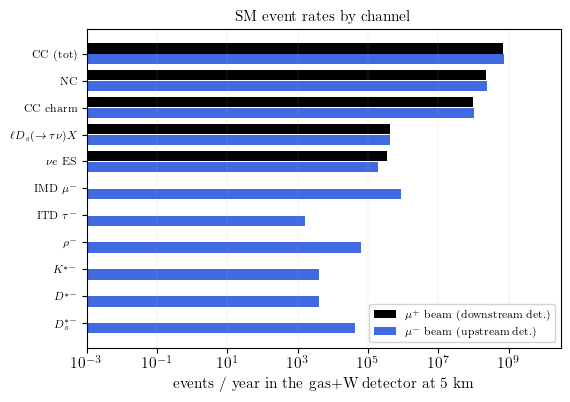

In [8]:
gas, Wm = det.gas, det.vertex_mat
col_N = det.nucleon_column()                                # nucleons / cm^2
col_e = det.electron_column()

def sig_es(E_, nui):
    return xsecs.nue_elastic_sigma(E_, nui)               # per electron

rates = {}
for side, fl in fluxes.items():
    r = {}
    for nui, E_, w_ in fl:
        def add(name, val):
            r[name] = r.get(name, 0.0) + val
        # CC-family rates carry the non-isoscalar (W-dominated column) correction
        cor_ = det.cc_correction(E_, nui)
        add("CC (tot)", np.sum(w_ * sigma_cc_tot(E_, nui) * cor_) * col_N)
        add("NC", np.sum(w_ * (xsecs.sigma_NC_nubar(E_) if "bar" in nui
                               else xsecs.sigma_NC_nu(E_))) * col_N)
        add("CC charm", np.sum(w_ * nts.sigma_charm_cc(E_, nui) * cor_) * col_N)
        add(r"$\ell D_s(\to\tau\nu)X$", np.sum(w_ * sigma_chain(E_, nui) * cor_) * col_N)
        add(r"$\nu e$ ES", np.sum(w_ * sig_es(E_, nui)) * col_e)
        if nui == "numu":
            add(r"IMD $\mu^-$", np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "numu", "m")) * col_e)
        if nui == "nuebar":
            add(r"IMD $\mu^-$", np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "nuebar", "m")) * col_e)
            add(r"ITD $\tau^-$", np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "nuebar", "t")) * col_e)
            add(r"$\rho^-$", np.sum(w_ * xsecs.sigma_resonant_rho(E_)) * col_e)
            add(r"$K^{*-}$", np.sum(w_ * xsecs.sigma_resonant_Kstar(E_)) * col_e)
            for lab, (M, f, v2, Gtot) in VRES.items():
                E_res = (M**2 - const.m_e**2) / (2 * const.m_e)
                dphi = w_[np.abs(E_ - E_res) < 250.0].sum() / 500.0
                add(lab, dphi * nwa_strength(M, f, v2) * col_e)
    rates[side] = r

order = ["CC (tot)", "NC", "CC charm", r"$\ell D_s(\to\tau\nu)X$", r"$\nu e$ ES",
         r"IMD $\mu^-$", r"ITD $\tau^-$", r"$\rho^-$", r"$K^{*-}$",
         r"$D^{*-}$", r"$D_s^{*-}$"]
print(f"{'channel':>28s} {'mu+ beam (down)':>18s} {'mu- beam (up)':>18s}")
for name in order:
    d = rates['down'].get(name, 0.0)
    u = rates['up'].get(name, 0.0)
    print(f"{name:>28s} {d:>18.3e} {u:>18.3e}")

fig, ax = pt.std_fig(figsize=(6, 4.2))
ypos = np.arange(len(order))[::-1]
ax.barh(ypos + 0.2, [rates['down'].get(n, 0.0) for n in order], height=0.38,
        color='black', label=r'$\mu^+$ beam (downstream det.)')
ax.barh(ypos - 0.2, [rates['up'].get(n, 0.0) for n in order], height=0.38,
        color='royalblue', label=r'$\mu^-$ beam (upstream det.)')
ax.set_yticks(ypos)
ax.set_yticklabels(order, fontsize=8)
ax.set_xscale('log')
ax.set_xlim(1e-3, 3e10)
ax.set_xlabel('events / year in the gas+W detector at 5 km')
ax.set_title('SM event rates by channel', fontsize=11)
ax.legend(frameon=True, fontsize=8, loc='lower right', framealpha=1.0,
          facecolor='white', edgecolor='lightgray')
ax.grid(axis='x', which='major', lw=0.3, alpha=0.4)
fig.savefig('plots/xsec_summary_rates.pdf', bbox_inches='tight', dpi=300)

## Spectral-line view: event rates per process and flavor

Each process is a level at its event rate in the **benchmark detector**, one
column per beam flavor component, drawn like an atomic term diagram — one
full-width figure per beam ($\mu^+$: $\bar\nu_\mu + \nu_e$; $\mu^-$:
$\nu_\mu + \bar\nu_e$). All NC channels are dashed. Colors follow the
colorblind-safe Okabe–Ito palette: black = inclusive DIS; vermillion = charm
production (CC tables; NC is the LO charm-sea-initiated CT18NNLO estimate —
gluon-fusion NLO not included, a mild lower bound; $D\to\mu$ uses the
dimuon-standard effective ${\rm BR} = 8.7\%$, $D_s\to\tau$ uses
$f_{c\to D_s}{\rm BR} = 0.08\times5.32\%$); blue = elastic $\nu e$
scattering (E$\nu$ES); orange = inverse lepton decays; reddish purple =
$s$-channel meson resonances ($\bar\nu_e$ only); bluish green = tridents,
all dilepton combinations, computed with NEPTUNE (coherent Woods–Saxon +
diffractive) on the gas and tungsten plates only.

In [9]:
import warnings
import neptune as nep
from parton import mkPDF

warnings.filterwarnings("ignore", category=RuntimeWarning)

FLAVORS = [("numubar", r"$\bar\nu_\mu$", "down", 0), ("nue", r"$\nu_e$", "down", 1),
           ("numu", r"$\nu_\mu$", "up", 0), ("nuebar", r"$\bar\nu_e$", "up", 1)]
FLUX = {nui: (fluxes[side][k][1], fluxes[side][k][2]) for nui, _, side, k in FLAVORS}

# ---- NC charm: LO charm-sea-initiated estimate (CT18NNLO, slow rescaling) ----
_pdf = mkPDF("CT18NNLO", 0)
SW2, M_NN, M_ZB, M_C = 0.2312, 0.9389, 91.19, 1.27
gLc, gRc = 0.5 - 2/3*SW2, -2/3*SW2

def sigma_nc_charm(E, n_x=40, n_y=20):
    xg = np.geomspace(2e-4, 0.5, n_x)
    yg = np.linspace(0.02, 0.98, n_y)
    dy = yg[1] - yg[0]
    dlx = np.log(xg[1] / xg[0])
    s2ME = 2 * M_NN * E
    tot = 0.0
    for x in xg:
        for y in yg:
            Q2 = max(s2ME * x * y, 2.0)
            xi = x * (1 + M_C**2 / Q2)
            if xi > 0.6:
                continue
            xc = _pdf.xfxQ2(4, xi, Q2) + _pdf.xfxQ2(-4, xi, Q2)
            prop = (M_ZB**2 / (Q2 + M_ZB**2)) ** 2
            tot += (const.Gf**2 * s2ME / (2*np.pi) * prop * xc
                    * (gLc**2 + gRc**2) * (1 + (1 - y)**2) * (x * dlx) * dy)
    return tot * const.invGeV2_to_cm2

NCC_EG = np.geomspace(100.0, 4800.0, 6)
NCC_SIG = np.array([sigma_nc_charm(E) for E in NCC_EG])   # nu = nubar (sea)
print("sigma_NC_charm / sigma_NC at 1.5 TeV:",
      f"{np.interp(1500., NCC_EG, NCC_SIG)/float(xsecs.sigma_NC_nu(1500.)):.3f}")

# ---- tridents with NEPTUNE: gas + tungsten plates only ----
TRI_EG = np.geomspace(120.0, 4800.0, 6)
# Nuclei per cm^2 of each signal medium. The vertex tracker is a graphite +
# silicon MIXTURE, whose .Z/.A are volume-fraction sums and not a nucleus at
# all, so resolve it to its dominant nucleus (carbon) first.
_vtx_nuc = dt.dominant_nucleus(Wm)
TRI_TARGETS = [(int(gas.Z), int(gas.A), dt.nuclei_density(gas) * DET_L),
               (int(_vtx_nuc.Z), int(_vtx_nuc.A),
                dt.nuclei_density(Wm) * (det.Z_VTX1 - det.Z_VTX0))]
LTEX = {"e": "e", "mu": r"\mu", "tau": r"\tau"}

def trident_channels(alpha):
    ch = [("e", "e"), ("mu", "mu"), ("tau", "tau")]
    ch += [(alpha, o) for o in ("e", "mu", "tau") if o != alpha]
    return ch

def trident_rate(alpha, is_nubar, l1, l2, E_, w_):
    rate = 0.0
    for Z, A, ncol in TRI_TARGETS:
        model = nep.TridentSMModel(nu_flavor=alpha, l1_flavor=l1, l2_flavor=l2,
                                   is_nubar=is_nubar)
        sig = []
        for En in TRI_EG:
            proc = nep.TridentProcess(model, Z=Z, A=A, Enu=float(En))
            sig.append(proc.sigma_total(nitn=3, neval=3000)["total_per_nucleus"][0])
        rate += np.sum(w_ * np.interp(E_, TRI_EG, np.array(sig), left=0.0)) * ncol
    return rate

# ---- per-column rates ----
BR_C_MU = 0.087   # effective semi-muonic BR of the charm-hadron mix (dimuon standard)

def column_rates(nui):
    E_, w_ = FLUX[nui]
    alpha = "mu" if "mu" in nui else "e"
    is_nb = "bar" in nui
    r, C = {}, {}
    def put(name, val, color):
        r[name], C[name] = val, color
    # CC-family rates carry the non-isoscalar (W-dominated column) correction
    cor_ = det.cc_correction(E_, nui)
    put("CC", np.sum(w_ * sigma_cc_tot(E_, nui) * cor_) * col_N, "k")
    put("NC", np.sum(w_ * (xsecs.sigma_NC_nubar(E_) if is_nb
                           else xsecs.sigma_NC_nu(E_))) * col_N, "k")
    s_cc = np.sum(w_ * nts.sigma_charm_cc(E_, nui) * cor_) * col_N
    s_nc = np.sum(w_ * np.interp(E_, NCC_EG, NCC_SIG)) * col_N
    put("CC (charm)", s_cc, "red")
    put("NC (charm)", s_nc, "red")
    put(r"CC ($D_s\!\to\!\tau$)", s_cc * nts.F_DS * nts.BR_DS_TAUNU, "red")
    put(r"NC ($D_s\!\to\!\tau$)", s_nc * nts.F_DS * nts.BR_DS_TAUNU, "red")
    put(r"CC ($D\!\to\!\mu$)", s_cc * BR_C_MU, "red")
    put(r"NC ($D\!\to\!\mu$)", s_nc * BR_C_MU, "red")
    put(r"E$\nu$ES", np.sum(w_ * sig_es(E_, nui)) * col_e, "royalblue")
    if nui == "numu":
        put(r"$\nu_\mu e\to\mu^-\nu_e$",
            np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "numu", "m")) * col_e,
            "darkorange")
    if nui == "nuebar":
        put(r"$\bar\nu_e e\to\mu^-\bar\nu_\mu$",
            np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "nuebar", "m")) * col_e,
            "darkorange")
        put(r"$\bar\nu_e e\to\tau^-\bar\nu_\tau$",
            np.sum(w_ * xsecs.inverse_lepton_decay_sigma(E_, "nuebar", "t")) * col_e,
            "darkorange")
        put(r"$\bar\nu_e e\to\rho^-$",
            np.sum(w_ * xsecs.sigma_resonant_rho(E_)) * col_e, "deeppink")
        put(r"$\bar\nu_e e\to K^{*-}$",
            np.sum(w_ * xsecs.sigma_resonant_Kstar(E_)) * col_e, "deeppink")
        for lab, (M, f, v2, Gtot) in VRES.items():
            E_res = (M**2 - const.m_e**2) / (2 * const.m_e)
            dphi = w_[np.abs(E_ - E_res) < 250.0].sum() / 500.0
            put(r"$\bar\nu_e e\to$ " + lab, dphi * nwa_strength(M, f, v2) * col_e,
                "deeppink")
    for l1, l2 in trident_channels(alpha):
        v = trident_rate(alpha, is_nb, l1, l2, E_, w_)
        if v > 1.0:
            put(rf"trident ${LTEX[l1]}\,{LTEX[l2]}$", v, "forestgreen")
    return r, C

RATES = {nui: column_rates(nui) for nui, *_ in FLAVORS}

print("columns computed:", {k: len(v[0]) for k, v in RATES.items()})

sigma_NC_charm / sigma_NC at 1.5 TeV: 0.028


columns computed: {'numubar': 14, 'nue': 14, 'numu': 15, 'nuebar': 20}


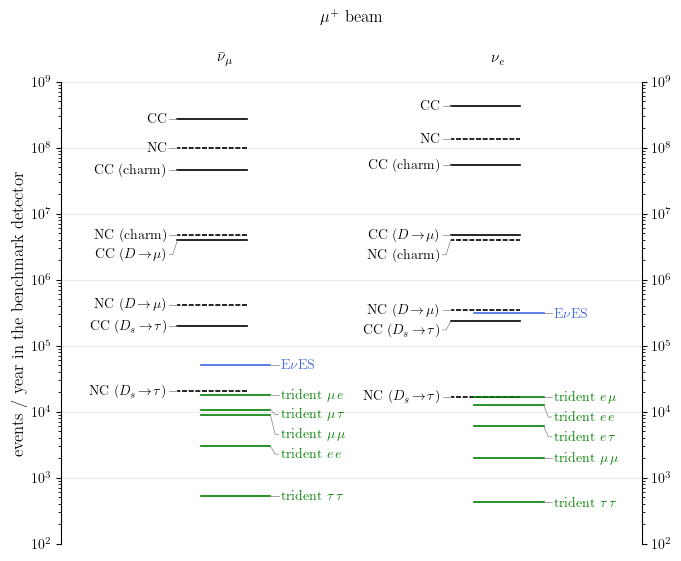

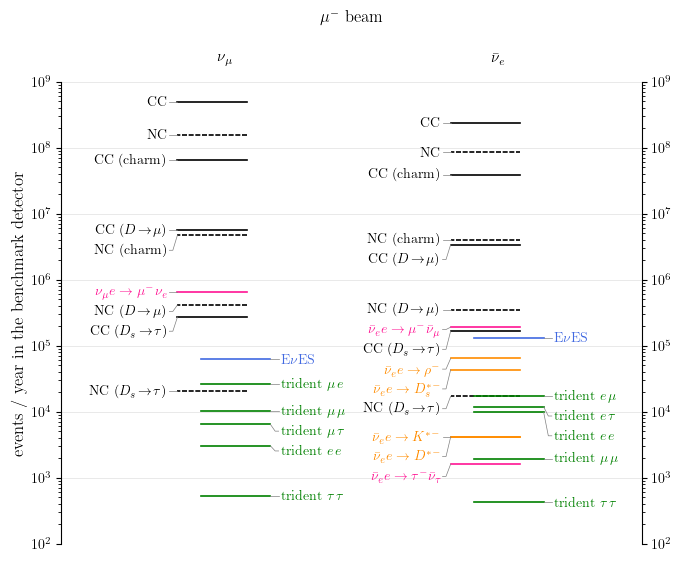

In [10]:
# Okabe-Ito colorblind-safe remap of the group colors stored in RATES
OI = {"k": "black", "red": "black", "royalblue": "royalblue",
      "darkorange": "deeppink", "deeppink": "darkorange", "forestgreen": "green",
      "purple": "#CC79A7"}

BEAMS = [("muplus", r"$\mu^+$ beam", [FLAVORS[0], FLAVORS[1]]),
         ("muminus", r"$\mu^-$ beam", [FLAVORS[2], FLAVORS[3]])]

for tag, header, cols in BEAMS:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    FS_LAB, FS_FLAV, FS_BEAM = 10, 11, 12
    bands = [(0.2, 0.36), (0.67, 0.83)]

    ax.set_yscale("log")
    ax.set_ylim(1e2, 1e9)
    ax.set_xlim(0.0, 1.0)
    ax.set_axisbelow(True)
    ax.grid(axis="y", which="major", color="0.88", lw=0.5, zorder=0)

    for (nui, ftex, side, k), (x0, x1) in zip(cols, bands):
        rr, CC_ = RATES[nui]
        w_band = x1 - x0
        def _on_right(n):
            return n.startswith("tri") or n.startswith("E$")
        groups = [([(n, v) for n, v in rr.items() if not _on_right(n)], False),
                  ([(n, v) for n, v in rr.items() if _on_right(n)], True)]
        for items, on_right in groups:
            items = sorted(items, key=lambda kv: kv[1], reverse=True)
            if not items:
                continue
            ly = np.log10([max(v, 1e-3) for _, v in items])
            lab_y = ly.copy()
            for i in range(1, len(lab_y)):
                lab_y[i] = min(lab_y[i], lab_y[i - 1] - 0.30)
            for (name, v), yl in zip(items, lab_y):
                c = OI.get(CC_[name], CC_[name])
                ls = (1, (3, 1)) if name.startswith("NC") else "-"
                if on_right:
                    ax.plot([x0 + 0.25 * w_band, x1], [v, v], color=c, lw=1.2, ls=ls)
                    ax.plot([x1, x1 + 0.008, x1 + 0.014], [v, 10**yl, 10**yl],
                            color="gray", lw=0.5)
                    ax.text(x1 + 0.018, 10**yl, name, ha="left", va="center",
                            fontsize=FS_LAB, color=c)
                else:
                    ax.plot([x0, x0 + 0.75 * w_band], [v, v], color=c, lw=1.2, ls=ls)
                    ax.plot([x0, x0 - 0.008, x0 - 0.014], [v, 10**yl, 10**yl],
                            color="gray", lw=0.5)
                    ax.text(x0 - 0.018, 10**yl, name, ha="right", va="center",
                            fontsize=FS_LAB, color=c)
        ax.text((x0 + x1) / 2, 2e9, ftex, ha="center", fontsize=FS_FLAV)
    ax.text(0.5, 0.8e10, header, ha="center", fontsize=FS_BEAM)

    ax.set_xticks([])
    ax.set_ylabel("events / year in the benchmark detector", fontsize=12)
    ax.tick_params(axis="y", labelsize=10)
    ax.yaxis.set_ticks_position("both")
    ax.tick_params(labelright=True)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    fig.savefig(f"plots/rates_summary_lines_{tag}.pdf", bbox_inches="tight", dpi=400)